# 🌾 Module 3 — Egypt FAO Yield Prediction (v17 — Corrected + Live APIs)
### Scenario Analysis & Climate Impact on Crop Yields



In [1]:
# ⏱️ ~2 minutes first run
!pip install scikit-learn pandas numpy matplotlib scipy xgboost -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
from google.colab import drive
import os, zipfile, glob, shutil

drive.mount('/content/drive')

# ✏️ غيّر المسار ده لو حطيت الـ files في مكان تاني على Drive
DRIVE_FOLDER = "/content/drive/MyDrive/Colab Notebooks/Hosny/data"

REQUIRED_ZIPS = [
    'Production_Crops_Livestock_E_All_Data_(Normalized).zip',
    'Environment_Temperature_change_E_All_Data_(Normalized).zip',
    'Inputs_FertilizersNutrient_E_All_Data_(Normalized).zip',
    'Inputs_Pesticides_Use_E_All_Data_(Normalized).zip',
    'Inputs_LandUse_E_All_Data_(Normalized).zip',
]

os.makedirs(DRIVE_FOLDER, exist_ok=True)
missing = [f for f in REQUIRED_ZIPS if not os.path.exists(os.path.join(DRIVE_FOLDER, f))]

if missing:
    print('⚠️  الملفات دي مش موجودة على Drive:')
    for mf in missing:
        print('   ❌ ' + mf)
    local_zips = glob.glob('/content/*.zip')
    if local_zips:
        print('✅ لقيت ' + str(len(local_zips)) + ' ZIP على /content/ — هنقلهم لـ Drive...')
        for zp in local_zips:
            fname = os.path.basename(zp)
            shutil.copy2(zp, os.path.join(DRIVE_FOLDER, fname))
            print('   💾 حُفظ: ' + fname)
        missing = [f for f in REQUIRED_ZIPS if not os.path.exists(os.path.join(DRIVE_FOLDER, f))]
    if missing:
        print('ارفع الـ ZIP files الـ 5 على Drive جوا المجلد: ' + DRIVE_FOLDER)
else:
    print('✅ كل الـ ZIP files موجودة على Drive')

existing_csvs = glob.glob('/content/*.csv')
if len(existing_csvs) < 5:
    print('📦 Extracting...')
    for fname in REQUIRED_ZIPS:
        zpath = os.path.join(DRIVE_FOLDER, fname)
        if os.path.exists(zpath):
            with zipfile.ZipFile(zpath, 'r') as z:
                z.extractall('/content/')
            print('   ✅ ' + fname)
        else:
            print('   ❌ مش موجود: ' + fname)
else:
    print('✅ CSVs موجودة (' + str(len(existing_csvs)) + ') — مش محتاج نفك الضغط تاني')

csvs = glob.glob('/content/*.csv')
print('\n📄 Files جاهزة (' + str(len(csvs)) + '):')
for cf in sorted(csvs):
    print('   ' + os.path.basename(cf) + '  (' + str(round(os.path.getsize(cf)/1e6, 1)) + ' MB)')


Mounted at /content/drive
✅ كل الـ ZIP files موجودة على Drive
📦 Extracting...
   ✅ Production_Crops_Livestock_E_All_Data_(Normalized).zip
   ✅ Environment_Temperature_change_E_All_Data_(Normalized).zip
   ✅ Inputs_FertilizersNutrient_E_All_Data_(Normalized).zip
   ✅ Inputs_Pesticides_Use_E_All_Data_(Normalized).zip
   ✅ Inputs_LandUse_E_All_Data_(Normalized).zip

📄 Files جاهزة (24):
   Environment_Temperature_change_E_All_Data_(Normalized).csv  (65.3 MB)
   Environment_Temperature_change_E_AreaCodes.csv  (0.0 MB)
   Environment_Temperature_change_E_Elements.csv  (0.0 MB)
   Environment_Temperature_change_E_Flags.csv  (0.0 MB)
   Inputs_FertilizersNutrient_E_All_Data_(Normalized).csv  (35.2 MB)
   Inputs_FertilizersNutrient_E_AreaCodes.csv  (0.0 MB)
   Inputs_FertilizersNutrient_E_Elements.csv  (0.0 MB)
   Inputs_FertilizersNutrient_E_Flags.csv  (0.0 MB)
   Inputs_FertilizersNutrient_E_ItemCodes.csv  (0.0 MB)
   Inputs_LandUse_E_All_Data_(Normalized).csv  (48.9 MB)
   Inputs_LandUse_E_A

In [3]:
import glob, os

COUNTRY     = "Egypt"
TRAIN_UNTIL = 2012        # ML train/test split: kept early to preserve a long 2013-2024 test set
BASELINE_UNTIL  = 2024    # end of the RECENT window for absolute kg/ha baseline (decoupled from the ML split)
RANDOM_SEED = 42

# ── Crop selection ──────────────────────────────────────────
USE_ALL_CROPS = False   # True = كل محاصيل مصر المتاحة في الداتا | False = قائمة الـ 36 المختارة
MIN_YEARS     = 10     # أقل عدد سنين بيانات للمحصول (يستبعد النادر زي الأفوكادو/البابايا)
EXCLUDE_KW    = ['Total', 'Primary', 'primary', 'Equivalent', 'eggs', 'n.e.c.']  # شيل الفئات المجمّعة + منتجات حيوانية

MAIN_CROPS = [  # 68 Egyptian crops with a real FAO Yield series (aggregates/eggs excluded)
    # Cereals
    'Wheat', 'Maize (corn)', 'Rice', 'Barley', 'Sorghum', 'Rye',
    # Fibre
    'Seed cotton, unginned', 'Flax, raw or retted', 'Jute, raw or retted',
    # Citrus
    'Oranges', 'Lemons and limes', 'Tangerines, mandarins, clementines',
    'Pomelos and grapefruits',
    # Other fruit
    'Mangoes, guavas and mangosteens', 'Bananas', 'Dates',
    'Apples', 'Pears', 'Quinces', 'Figs', 'Grapes', 'Strawberries',
    'Apricots', 'Peaches and nectarines', 'Plums and sloes', 'Other stone fruits',
    'Walnuts, in shell',
    # Fruiting vegetables
    'Tomatoes', 'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
    'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
    'Eggplants (aubergines)', 'Cucumbers and gherkins', 'Watermelons',
    'Cantaloupes and other melons', 'Pumpkins, squash and gourds', 'Okra',
    # Roots / tubers / bulbs
    'Potatoes', 'Sweet potatoes', 'Taro',
    'Onions and shallots, dry (excluding dehydrated)', 'Green garlic',
    # Leafy / brassica
    'Cabbages', 'Cauliflowers and broccoli', 'Carrots and turnips',
    'Lettuce and chicory', 'Spinach', 'Artichokes',
    # Pulses
    'Broad beans and horse beans, dry', 'Broad beans and horse beans, green',
    'Lentils, dry', 'Chick peas, dry', 'Cow peas, dry', 'Peas, dry', 'Peas, green',
    'Beans, dry', 'Other beans, green', 'String beans', 'Lupins', 'Vetches',
    # Oil crops
    'Groundnuts, excluding shelled', 'Sesame seed', 'Sunflower seed',
    'Soya beans', 'Linseed', 'Olives',
    # Sugar
    'Sugar beet', 'Sugar cane',
    # Spices
    'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
]

CROP_RENAME = {
    'Maize (corn)': 'Maize', 'Seed cotton, unginned': 'Cotton',
    'Lemons and limes': 'Lemons', 'Tangerines, mandarins, clementines': 'Tangerines',
    'Pomelos and grapefruits': 'Grapefruit',
    'Mangoes, guavas and mangosteens': 'Mangoes',
    'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)': 'Peppers (green)',
    'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw': 'Peppers (dry)',
    'Onions and shallots, dry (excluding dehydrated)': 'Onions', 'Green garlic': 'Garlic',
    'Eggplants (aubergines)': 'Eggplants', 'Cucumbers and gherkins': 'Cucumbers',
    'Cantaloupes and other melons': 'Melons', 'Pumpkins, squash and gourds': 'Pumpkins',
    'Cauliflowers and broccoli': 'Cauliflower & Broccoli',
    'Carrots and turnips': 'Carrots', 'Lettuce and chicory': 'Lettuce',
    'Broad beans and horse beans, dry': 'Broad Beans (dry)',
    'Broad beans and horse beans, green': 'Broad Beans (green)',
    'Lentils, dry': 'Lentils', 'Chick peas, dry': 'Chickpeas', 'Cow peas, dry': 'Cowpeas',
    'Peas, dry': 'Peas (dry)', 'Peas, green': 'Peas (green)',
    'Beans, dry': 'Beans (dry)', 'Other beans, green': 'Beans (green)',
    'Groundnuts, excluding shelled': 'Groundnuts', 'Sesame seed': 'Sesame',
    'Sunflower seed': 'Sunflower', 'Soya beans': 'Soybeans', 'Sweet potatoes': 'Sweet Potatoes',
    'Peaches and nectarines': 'Peaches', 'Plums and sloes': 'Plums',
    'Other stone fruits': 'Stone Fruits (other)', 'Walnuts, in shell': 'Walnuts',
    'Flax, raw or retted': 'Flax', 'Jute, raw or retted': 'Jute',
    'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw': 'Spices',
}

def find_file(keyword):
    matches = glob.glob(f'/content/*{keyword}*.csv')
    if not matches:
        raise FileNotFoundError(f"❌ File '{keyword}' not found!")
    return matches[0]

PATH_PRODUCTION  = find_file('Production_Crops_Livestock_E_All_Data_(Normalized)')
PATH_TEMPERATURE = find_file('Environment_Temperature_change_E_All_Data_(Normalized)')
PATH_FERTILIZERS = find_file('Inputs_FertilizersNutrient_E_All_Data_(Normalized)')
PATH_PESTICIDES  = find_file('Inputs_Pesticides_Use_E_All_Data_(Normalized)')
PATH_LANDUSE     = find_file('Inputs_LandUse_E_All_Data_(Normalized)')

print("✅ All files found")
print(f"🌾 Mode: {'ALL-CROPS' if USE_ALL_CROPS else 'CURATED'} (curated list has {len(MAIN_CROPS)} crops)")

✅ All files found
🌾 Mode: CURATED (curated list has 68 crops)


In [4]:
import urllib.request, urllib.parse, urllib.error, json as _json, ssl, pandas as pd, numpy as np
from datetime import datetime, timedelta
import time
import os

USE_API        = True
FAO_BASE       = 'https://fenixservices.fao.org/faostat/api/v1/en/data/'
EGYPT_FAO_CODE = '59'
YEAR_START     = 1961
_END_DT        = datetime.now() - timedelta(days=7)
END_DATE       = _END_DT.strftime('%Y-%m-%d')
YEAR_END       = _END_DT.year

def _get_json(url, timeout=90):
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=timeout, context=ctx) as r:
        return _json.loads(r.read().decode('utf-8'))

def _errinfo(e):
    if isinstance(e, urllib.error.HTTPError):
        try:
            _body = e.read().decode('utf-8', 'replace')[:200]
            _body = _body.replace('\n', ' ')
        except Exception:
            _body = ''
        return 'HTTP ' + str(e.code) + ' ' + str(getattr(e, 'reason', '')) + ' | ' + _body
    if isinstance(e, urllib.error.URLError):
        return 'URLError: ' + str(getattr(e, 'reason', e))
    return type(e).__name__ + ': ' + str(e)

def get_faostat(domain, elements, items=None):
    params = {'area': EGYPT_FAO_CODE, 'element': ','.join(elements), 'output_type': 'objects'}
    if items:
        params['item'] = ','.join(items)
    url = FAO_BASE + domain + '?' + urllib.parse.urlencode(params)
    rows = _get_json(url).get('data', [])
    df = pd.DataFrame(rows)
    if len(df):
        df['Year']  = pd.to_numeric(df.get('Year'),  errors='coerce')
        df['Value'] = pd.to_numeric(df.get('Value'), errors='coerce')
        if 'Months' not in df.columns:
            df['Months'] = 'Annual'
    return df

CLIMATE_POINTS = [(30.8, 31.0), (26.2, 31.9)]  # North Delta + Middle/Upper Egypt (2 zones; lighter API load, anomalies spatially uniform)
OM_BASE = 'https://archive-api.open-meteo.com/v1/archive'

WEATHER_CSV = 'egypt_weather_daily_' + str(YEAR_START) + '_' + str(YEAR_END) + '.csv'
# Cache the daily weather file so re-runs DON'T re-hit Open-Meteo's hourly
# rate limit. Look on Drive first (persists across Colab sessions), else local.
try:
    _CACHE_DIR = DRIVE_FOLDER
except NameError:
    _CACHE_DIR = '/content'
_CACHE_PATHS = [os.path.join(_CACHE_DIR, WEATHER_CSV), WEATHER_CSV, '/content/' + WEATHER_CSV]

def _save_weather(allf):
    out = allf.rename(columns={'time': 'Date', 'tmax': 'Max_Temperature_C',
                               'tmin': 'Min_Temperature_C', 't': 'Mean_Temperature_C',
                               'p': 'Precipitation_mm'})[['Date', 'Max_Temperature_C',
                               'Min_Temperature_C', 'Mean_Temperature_C', 'Precipitation_mm']]
    for _dest in {WEATHER_CSV, os.path.join(_CACHE_DIR, WEATHER_CSV)}:
        try:
            out.to_csv(_dest, index=False, encoding='utf-8-sig')
            print('  💾 Saved: ' + _dest + ' (' + str(len(out)) + ' days)')
        except Exception as _e:
            print('  ⚠️ Could not save to ' + _dest + ' (' + type(_e).__name__ + ')')

def get_climate():
    # ---- CACHE-FIRST: reuse the downloaded daily file if present (no API call) ----
    allf = None
    for _cp in _CACHE_PATHS:
        if os.path.exists(_cp):
            allf = pd.read_csv(_cp).rename(columns={'Date': 'time', 'Max_Temperature_C': 'tmax',
                'Min_Temperature_C': 'tmin', 'Mean_Temperature_C': 't', 'Precipitation_mm': 'p'})
            print('  📁 Climate: loaded cached daily file (no API call) -> ' + _cp)
            break
    if allf is None:
        # ---- COLD FETCH from Open-Meteo (first time only) ----
        n = len(CLIMATE_POINTS)
        frames = []
        for i, (lat, lon) in enumerate(CLIMATE_POINTS):
            p = {
                'latitude': lat, 'longitude': lon,
                'start_date': str(YEAR_START) + '-01-01',
                'end_date': END_DATE,
                'daily': 'temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum',
                'timezone': 'UTC'
            }
            url = OM_BASE + '?' + urllib.parse.urlencode(p)
            for attempt in range(4):
                try:
                    d = _get_json(url, timeout=300)['daily']
                    frames.append(pd.DataFrame({
                        'time': d['time'],
                        'tmax': d['temperature_2m_max'],
                        'tmin': d['temperature_2m_min'],
                        't':    d['temperature_2m_mean'],
                        'p':    d['precipitation_sum']
                    }))
                    print('  ✅ Point ' + str(i+1) + '/' + str(n) + ' fetched (' + str(len(d['time'])) + ' days)')
                    time.sleep(2)
                    break
                except urllib.error.HTTPError as e:
                    _msg = _errinfo(e).lower()
                    if e.code == 429 and attempt < 3 and 'hour' not in _msg:
                        print('  ⏳ Point ' + str(i+1) + '/' + str(n) + ' rate limited (per-minute), waiting 65s...')
                        time.sleep(65)
                    else:
                        if 'hour' in _msg:
                            print('  ⛔ Open-Meteo HOURLY limit reached - re-run next hour; using CSV fallback now.')
                        raise
        allf = pd.concat(frames).groupby('time').mean(numeric_only=True).reset_index()
        _save_weather(allf)
    allf['time']  = pd.to_datetime(allf['time'])
    allf['year']  = allf['time'].dt.year
    allf['month'] = allf['time'].dt.month
    _last     = allf.groupby('year')['month'].max()
    _complete = set(_last[_last >= 12].index)
    cf = allf[allf['year'].isin(_complete)]
    ann = cf.groupby('year').agg(
        temp_mean_c=('t', 'mean'), tmax_mean_c=('tmax', 'mean'),
        tmin_mean_c=('tmin', 'mean'), precip_mm=('p', 'sum')
    ).reset_index()
    summer = cf[cf['month'].isin([6,7,8,9])].groupby('year').agg(
        summer_temp_c=('t', 'mean'), summer_tmax_c=('tmax', 'mean'),
        summer_precip_mm=('p', 'sum'),
        summer_hot_days=('tmax', lambda x: int((x > 35).sum()))
    ).reset_index()
    winter = cf[cf['month'].isin([12,1,2])].groupby('year').agg(
        winter_temp_c=('t', 'mean')
    ).reset_index()
    b  = ann[ann['year'].between(1961,1990)]['temp_mean_c'].mean()
    sb = summer[summer['year'].between(1961,1990)]['summer_temp_c'].mean()
    wb = winter[winter['year'].between(1961,1990)]['winter_temp_c'].mean()
    ann['temp_change_c']          = ann['temp_mean_c']    - b
    summer['summer_temp_anomaly'] = summer['summer_temp_c'] - sb
    winter['winter_temp_anomaly'] = winter['winter_temp_c'] - wb
    return ann, summer, winter

API_PROD = API_FERT = API_PEST = API_LAND = None
API_ANN  = API_SUMMER = API_WINTER = None

if USE_API:
    print('🌐 Fetching live climate (FAOSTAT data is read from the official local CSV files)...')
    # NOTE: the FAOSTAT REST API (fenixservices) is frequently down (HTTP 521),
    # and the official FAO bulk CSVs are already loaded in the next cell, so we
    # skip the live FAOSTAT calls (faster, no noisy fallback warnings) and pull
    # only the live Open-Meteo climate, which works.
    try:
        API_ANN, API_SUMMER, API_WINTER = get_climate()
        print('  ✅ Climate OK: ' + str(len(API_ANN)) + ' years (' + str(YEAR_START) + '-' + str(YEAR_END) + ')')
    except Exception as e:
        print('  ⚠️ Climate failed → FAO CSV fallback (' + _errinfo(e) + ')')
else:
    print('USE_API = False → using local CSV files only')


🌐 Fetching live climate (FAOSTAT data is read from the official local CSV files)...
  📁 Climate: loaded cached daily file (no API call) -> /content/drive/MyDrive/Colab Notebooks/Hosny/data/egypt_weather_daily_1961_2026.csv
  ✅ Climate OK: 65 years (1961-2026)


In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f"🔄 Loading {COUNTRY} data (API-first, CSV fallback)...")

def _source(api_df, path, label):
    if api_df is not None and len(api_df) > 0:
        print(f"  🌐 {label}: from API")
        return api_df.copy()
    print(f"  📁 {label}: from local CSV")
    return pd.read_csv(path, encoding='latin-1', low_memory=False)

# 1. Yield + Area
prod_df  = _source(API_PROD, PATH_PRODUCTION, 'Crops')
egypt    = prod_df[prod_df['Area'] == COUNTRY]
yield_df = egypt[egypt['Element'] == 'Yield'][['Item','Year','Value']].rename(
    columns={'Value':'yield_kg_ha','Item':'crop','Year':'year'})
area_df  = egypt[egypt['Element'] == 'Area harvested'][['Item','Year','Value']].rename(
    columns={'Value':'area_ha','Item':'crop','Year':'year'})

if USE_ALL_CROPS:
    # Auto-detect EVERY Egyptian crop with a real Yield series, dropping
    # aggregate categories (Totals/Primary/Equivalent) + animal products (eggs)
    # so the national area-weighted average never double-counts.
    import re as _re
    _yv  = yield_df.copy(); _yv['yield_kg_ha'] = pd.to_numeric(_yv['yield_kg_ha'], errors='coerce')
    _cnt = _yv.dropna(subset=['yield_kg_ha']).groupby('crop')['year'].nunique()
    _pat = '|'.join(_re.escape(k) for k in EXCLUDE_KW)
    _bad = _cnt.index.to_series().str.contains(_pat)
    SELECTED = sorted(_cnt[(~_bad) & (_cnt >= MIN_YEARS)].index)
    print(f"  🌾 ALL-CROPS mode: {len(SELECTED)} crops (>= {MIN_YEARS} yrs, aggregates/eggs removed)")
else:
    SELECTED = MAIN_CROPS
    print(f"  🌾 CURATED mode: {len(SELECTED)} hand-picked crops")

yield_df = yield_df[yield_df['crop'].isin(SELECTED)].copy()
yield_df['crop'] = yield_df['crop'].replace(CROP_RENAME)
area_df  = area_df[area_df['crop'].isin(SELECTED)].copy()
area_df['crop'] = area_df['crop'].replace(CROP_RENAME)
print(f"  ✅ Production: {len(yield_df)} records | {yield_df['crop'].nunique()} crops")

# 2. Temperature (+ precipitation) — API real climate OR FAO CSV anomaly
HAS_PRECIP = False
if API_ANN is not None:
    temp_ann = API_ANN[['year','temp_change_c','temp_mean_c','tmax_mean_c','tmin_mean_c','precip_mm']].copy()
    summer_a = API_SUMMER[['year','summer_temp_anomaly','summer_temp_c','summer_tmax_c','summer_precip_mm','summer_hot_days']].copy()
    winter_a = API_WINTER[['year','winter_temp_anomaly','winter_temp_c']].copy()
    HAS_PRECIP = True
    print(f"  ✅ Temperature: API real climate | {len(temp_ann)} yrs | range "
          f"{temp_ann['temp_change_c'].min():.2f} to {temp_ann['temp_change_c'].max():.2f} °C (+ precip)")
else:
    temp_df  = pd.read_csv(PATH_TEMPERATURE, encoding='latin-1', low_memory=False)
    eg_temp  = temp_df[(temp_df['Area'] == COUNTRY) & (temp_df['Element'] == 'Temperature change')]
    temp_ann = eg_temp[eg_temp['Months'] == 'Meteorological year'][['Year','Value']].rename(
        columns={'Value':'temp_change_c','Year':'year'}).groupby('year')['temp_change_c'].mean().reset_index()
    summer_a = eg_temp[eg_temp['Months'].isin(['June','July','August','September'])].groupby(
        'Year')['Value'].mean().reset_index().rename(columns={'Value':'summer_temp_anomaly','Year':'year'})
    winter_a = eg_temp[eg_temp['Months'].isin(['December','January','February'])].groupby(
        'Year')['Value'].mean().reset_index().rename(columns={'Value':'winter_temp_anomaly','Year':'year'})
    print(f"  ✅ Temperature: FAO CSV anomaly | {len(temp_ann)} yrs | range "
          f"{temp_ann['temp_change_c'].min():.2f} to {temp_ann['temp_change_c'].max():.2f} °C")

# 3. Fertilizers
fert_df  = _source(API_FERT, PATH_FERTILIZERS, 'Fertilizers')
eg_f     = fert_df[fert_df['Area'] == COUNTRY]
nitro    = eg_f[(eg_f['Item'].str.contains('nitrogen',case=False)) &
               (eg_f['Element']=='Agricultural Use')][['Year','Value']].rename(
    columns={'Value':'nitrogen_t','Year':'year'}).groupby('year')['nitrogen_t'].sum().reset_index()
phos     = eg_f[(eg_f['Item'].str.contains('phosphate',case=False)) &
               (eg_f['Element']=='Agricultural Use')][['Year','Value']].rename(
    columns={'Value':'phosphate_t','Year':'year'}).groupby('year')['phosphate_t'].sum().reset_index()
print(f"  ✅ Fertilizers: {len(nitro)} N-years | {len(phos)} P-years")

# 4. Pesticides
pest_df  = _source(API_PEST, PATH_PESTICIDES, 'Pesticides')
eg_p     = pest_df[(pest_df['Area']==COUNTRY) & (pest_df['Item']=='Pesticides (total)') &
                   (pest_df['Element']=='Agricultural Use')][['Year','Value']].rename(
    columns={'Value':'pesticides_t','Year':'year'})
print(f"  ✅ Pesticides: {len(eg_p)} years")

# 5. Land Use
land_df  = _source(API_LAND, PATH_LANDUSE, 'Land Use')
arable   = land_df[(land_df['Area']==COUNTRY) & (land_df['Item']=='Arable land') &
                   (land_df['Element']=='Area')][['Year','Value']].rename(
    columns={'Value':'arable_1000ha','Year':'year'})
print(f"  ✅ Land Use: {len(arable)} years")

# Merge all
df = yield_df.merge(area_df, on=['crop','year'], how='left')
for tbl in [temp_ann, summer_a, winter_a, nitro, phos, eg_p, arable]:
    df = df.merge(tbl, on='year', how='left')
df = df.sort_values(['crop','year']).reset_index(drop=True)
INTERP = ['nitrogen_t','phosphate_t','pesticides_t','arable_1000ha','area_ha']
if HAS_PRECIP: INTERP += ['temp_mean_c','tmax_mean_c','tmin_mean_c','precip_mm','summer_temp_c','summer_tmax_c','summer_precip_mm','summer_hot_days','winter_temp_c']
for col in INTERP:
    if col in df.columns:
        df[col] = df.groupby('crop')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both'))
df = df.dropna(subset=['yield_kg_ha','temp_change_c'])

print(f"\n📊 Final dataset: {df.shape[0]} records | {df['crop'].nunique()} crops | {df['year'].min()}-{df['year'].max()}")
if HAS_PRECIP: print("   💧 Extra API features: tmax/tmin/mean temp, precip, summer hot-days (>35C)")


🔄 Loading Egypt data (API-first, CSV fallback)...
  📁 Crops: from local CSV
  🌾 CURATED mode: 68 hand-picked crops
  ✅ Production: 4134 records | 68 crops
  ✅ Temperature: API real climate | 65 yrs | range -0.86 to 2.40 °C (+ precip)
  📁 Fertilizers: from local CSV
  ✅ Fertilizers: 63 N-years | 63 P-years
  📁 Pesticides: from local CSV
  ✅ Pesticides: 34 years
  📁 Land Use: from local CSV
  ✅ Land Use: 63 years

📊 Final dataset: 4134 records | 68 crops | 1961-2024
   💧 Extra API features: tmax/tmin/mean temp, precip, summer hot-days (>35C)


In [6]:
from sklearn.preprocessing import LabelEncoder

# Per-crop linear DETREND on training years, then standardize the residual.
# The model learns the standardized year-to-year DEVIATION (weather/inputs);
# the long-run level is carried by the trend line and added back later.
le = LabelEncoder()
df['crop_enc'] = le.fit_transform(df['crop'])

def fit_and_detrend(grp):
    train_g = grp[grp['year'] <= TRAIN_UNTIL]
    grp = grp.copy()
    if len(train_g) < 4:
        grp['trend_yield']   = grp['yield_kg_ha'].mean()
        grp['yield_detrend'] = grp['yield_kg_ha'] - grp['yield_kg_ha'].mean()
        return grp
    coeffs = np.polyfit(train_g['year'], train_g['yield_kg_ha'], 1)
    trend  = np.polyval(coeffs, grp['year'])
    grp['trend_yield']   = trend
    grp['yield_detrend'] = grp['yield_kg_ha'] - trend
    return grp

df = pd.concat([fit_and_detrend(g) for _, g in df.groupby('crop')]).sort_index()

# Feature engineering
df['year_norm']      = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min())
df['year_sq']        = df['year_norm'] ** 2
df['decade']         = (df['year'] // 10) * 10
df['n_intensity']    = df['nitrogen_t']   / (df['arable_1000ha'] * 1000).clip(lower=1)
df['p_intensity']    = df['phosphate_t']  / (df['arable_1000ha'] * 1000).clip(lower=1)
df['pest_intensity'] = df['pesticides_t'] / (df['arable_1000ha'] * 1000).clip(lower=1)
df['np_ratio']       = (df['nitrogen_t'] / df['phosphate_t'].clip(lower=1)).clip(0, 20)
df['temp_5y']        = df.groupby('crop')['temp_change_c'].transform(
    lambda x: x.rolling(5, min_periods=2).mean())
df['temp_x_n']       = df['temp_change_c'] * df['n_intensity']
df['summer_x_n']     = df['summer_temp_anomaly'] * df['n_intensity']
df['log_n']          = np.log1p(df['nitrogen_t'])
df['log_pest']       = np.log1p(df['pesticides_t'].clip(lower=0))

def add_crop_std(grp):
    train_g = grp[grp['year'] <= TRAIN_UNTIL]
    std = train_g['yield_detrend'].std()
    if pd.isna(std) or std < 50: std = 50
    grp = grp.copy()
    grp['crop_yield_std']   = std
    grp['yield_detrend_std'] = grp['yield_detrend'] / std
    return grp

df = pd.concat([add_crop_std(g) for _, g in df.groupby('crop')]).sort_index()
df_m = df.dropna(subset=['temp_5y']).copy()

ML_FEATURES = [
    'year_norm', 'year_sq', 'decade',
    'temp_change_c', 'temp_5y', 'summer_temp_anomaly', 'winter_temp_anomaly',
    'nitrogen_t', 'phosphate_t', 'pesticides_t',
    'n_intensity', 'p_intensity', 'pest_intensity', 'np_ratio',
    'arable_1000ha',
    'temp_x_n', 'summer_x_n', 'log_n', 'log_pest',
]
TARGET = 'yield_detrend_std'

# 🌐 If the climate API supplied real temperature + precipitation, use them as extra features
for _extra in ['temp_mean_c', 'tmax_mean_c', 'tmin_mean_c', 'precip_mm', 'summer_tmax_c', 'summer_precip_mm', 'summer_hot_days']:
    if _extra in df_m.columns and df_m[_extra].notna().any():
        if _extra not in ML_FEATURES:
            ML_FEATURES.append(_extra)
        print(f'   ➕ added API feature: {_extra}')

print('✅ Feature engineering done!')
print(f'   Records: {len(df_m)} | Features: {len(ML_FEATURES)}')
print(f'   Split: train ≤ {TRAIN_UNTIL} | test > {TRAIN_UNTIL}')
print(f'   Standardized target std: {df_m["yield_detrend_std"].std():.3f}')


   ➕ added API feature: temp_mean_c
   ➕ added API feature: tmax_mean_c
   ➕ added API feature: tmin_mean_c
   ➕ added API feature: precip_mm
   ➕ added API feature: summer_tmax_c
   ➕ added API feature: summer_precip_mm
   ➕ added API feature: summer_hot_days
✅ Feature engineering done!
   Records: 4066 | Features: 26
   Split: train ≤ 2012 | test > 2012
   Standardized target std: 1.277


In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

X = df_m[ML_FEATURES].fillna(df_m[ML_FEATURES].median())
y = df_m[TARGET]

train_mask = df_m['year'] <= TRAIN_UNTIL
test_mask  = df_m['year'] >  TRAIN_UNTIL
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

trend_test    = df_m[test_mask]['trend_yield'].values
crop_std_test = df_m[test_mask]['crop_yield_std'].values
abs_actual    = df_m[test_mask]['yield_kg_ha'].values

def predict_abs_yield(X_input, model, trend_arr, crop_std_arr):
    dev_std = model.predict(X_input)
    return dev_std * crop_std_arr + trend_arr

models = {
    'Random Forest': RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=5,
                                           random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=400, learning_rate=0.04, max_depth=4,
                                           subsample=0.8, min_samples_leaf=5, random_state=RANDOM_SEED),
    'XGBoost': XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8,
                            colsample_bytree=0.8, random_state=RANDOM_SEED, verbosity=0),
}

# 🔍 HONEST EVALUATION
# trend-only baseline: predict deviation = 0  (i.e. pure per-crop trend line)
ss_tot       = np.sum((abs_actual - abs_actual.mean())**2)
trend_only_r2 = 1 - np.sum((abs_actual - trend_test)**2) / ss_tot

results = {}
print(f"{'Model':20s} | R²(abs) | R²(deviation=skill) | RMSE | MAE")
print('-' * 78)
for name, model in models.items():
    model.fit(X_train, y_train)
    abs_preds  = predict_abs_yield(X_test, model, trend_test, crop_std_test)
    r2_abs     = r2_score(abs_actual, abs_preds)
    r2_skill   = r2_score(y_test, model.predict(X_test))   # on what it actually predicts
    rmse       = mean_squared_error(abs_actual, abs_preds) ** 0.5
    mae        = mean_absolute_error(abs_actual, abs_preds)
    results[name] = {'model': model, 'r2_abs': r2_abs, 'r2_skill': r2_skill, 'rmse': rmse, 'mae': mae}
    print(f'{name:20s} | {r2_abs:6.3f} | {r2_skill:18.3f} | {rmse:7.0f} | {mae:6.0f}')

print('-' * 78)
print(f"{'TREND-ONLY baseline':20s} | {trend_only_r2:6.3f} | {'(no model)':>18s} |")

# choose the model with the best REAL skill (on the deviation target)
best_name  = max(results, key=lambda k: results[k]['r2_skill'])
best_model = results[best_name]['model']

ml_gain = results[best_name]['r2_abs'] - trend_only_r2
print(f'\n🏆 Best model (by real skill): {best_name}')
print()
print('='*74)
print('⚠️  KEY RESULT FOR THE READER  /  نتيجة مهمة للقارئ')
print('='*74)
print(f'   Trend-only baseline R² : {trend_only_r2:+.3f}')
print(f'   Best ML model R² (abs) : {results[best_name]["r2_abs"]:+.3f}   (gain over trend: {ml_gain:+.3f})')
print(f'   Best ML model R² (skill): {results[best_name]["r2_skill"]:+.3f}   (on year-to-year deviations — its real job)')
_verdict = ('does NOT add real value over a simple trend line' if ml_gain < 0.01
            else 'adds only modest value over a simple trend line')
print(f'   ➡️  VERDICT: the ML model {_verdict}.')
print('       الموديل لا يتفوق فعليًا على خط الاتجاه — استخدم محرك الحساسية')
print('       الزراعية (الخلية التالية) للسيناريوهات المناخية، ليس هذا الموديل.')
print('='*74)
print('\n⚠️  Details:')
print(f'   • R²(abs)≈{results[best_name]["r2_abs"]:.2f} looks great, but the TREND-ONLY')
print(f'     baseline already reaches R²={trend_only_r2:.2f} — so almost all of the')
print('     "accuracy" is the per-crop trend line, NOT the ML model.')
print(f'   • R² on the deviation target (the model\'s real job) is')
print(f'     {results[best_name]["r2_skill"]:+.2f}: year-to-year yield deviations in Egypt')
print('     are NOT well explained by national climate/input anomalies')
print('     (irrigated agriculture is buffered + warming correlates with the')
print('     technology uptrend). We therefore do NOT use this model to invent')
print('     climate scenarios — see the agronomic engine below.')

importances = pd.Series(best_model.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)
print('\n🎯 Top 10 features:')
for feat, imp in importances.head(10).items():
    print(f'  {feat:22s} {imp:.3f}  ' + '█' * int(imp*60))


Model                | R²(abs) | R²(deviation=skill) | RMSE | MAE
------------------------------------------------------------------------------
Random Forest        |  0.943 |             -0.000 |    4054 |   2254
Gradient Boosting    |  0.944 |             -0.002 |    4003 |   2230
XGBoost              |  0.946 |             -0.009 |    3934 |   2199
------------------------------------------------------------------------------
TREND-ONLY baseline  |  0.943 |         (no model) |

🏆 Best model (by real skill): Random Forest

⚠️  KEY RESULT FOR THE READER  /  نتيجة مهمة للقارئ
   Trend-only baseline R² : +0.943
   Best ML model R² (abs) : +0.943   (gain over trend: -0.001)
   Best ML model R² (skill): -0.000   (on year-to-year deviations — its real job)
   ➡️  VERDICT: the ML model does NOT add real value over a simple trend line.
       الموديل لا يتفوق فعليًا على خط الاتجاه — استخدم محرك الحساسية
       الزراعية (الخلية التالية) للسيناريوهات المناخية، ليس هذا الموديل.

⚠️  Details:


In [8]:
# ==================================================================
# 🌍 SCENARIO ANALYSIS — transparent AGRONOMIC sensitivity engine
#
# WHY NOT THE ML MODEL: tree models cannot extrapolate beyond the training
# range, so +2/+3 °C shocks collapsed every scenario to ~0%. And the data
# shows NO empirical climate-damage signal (warming correlates with the
# technology uptrend). So scenarios use published crop sensitivities instead.
#
# Sensitivities (% yield change per +1 °C effective warming) are central
# estimates from IPCC AR6 Ch.5 and FAO/agronomic literature (e.g. Asseng et
# al. 2015 for wheat ~ -6%/°C, maize ~ -7%/°C). Adjust as needed.
# ==================================================================

CEREAL, SUMMER_VEG, LEGUME, FRUIT, ROOT, SUGAR, DEF = -0.060, -0.050, -0.055, -0.035, -0.045, -0.035, -0.045
TEMP_SENS = {
    'Wheat':CEREAL,'Maize':-0.070,'Rice':-0.060,'Barley':CEREAL,
    # Per-crop heat tolerance (differentiated, not one flat veg rate):
    # tomato & pepper fail flower/fruit-set in heat (most sensitive);
    # eggplant/watermelon/okra are heat-loving C-season crops (most tolerant).
    'Tomatoes':-0.055,'Peppers (green)':-0.058,'Eggplants':-0.040,
    'Cucumbers':-0.050,'Watermelons':-0.038,'Okra':-0.030,
    'Cabbages':-0.045,'Carrots':-0.045,'Artichokes':-0.040,
    'Potatoes':-0.075,'Sweet Potatoes':-0.045,'Onions':-0.045,
    'Broad Beans (dry)':LEGUME,'Lentils':LEGUME,'Chickpeas':LEGUME,
    'Groundnuts':LEGUME,'Sesame':-0.045,'Sunflower':-0.050,
    'Oranges':FRUIT,'Lemons':FRUIT,'Tangerines':FRUIT,'Mangoes':-0.030,
    'Bananas':-0.045,'Dates':-0.020,'Apples':-0.050,'Figs':-0.035,
    'Grapes':-0.040,'Strawberries':-0.055,'Olives':-0.030,
    'Cotton':-0.040,'Sugar cane':-0.030,'Sugar beet':-0.040,
    # ── newly added crops (central literature estimates, %/°C) ──
    'Sorghum':-0.045,'Rye':CEREAL,'Soybeans':-0.060,
    'Beans (dry)':LEGUME,'Beans (green)':-0.050,'Broad Beans (green)':-0.050,
    'Cowpeas':-0.045,'Peas (dry)':LEGUME,'Peas (green)':LEGUME,'Lupins':-0.050,'Vetches':-0.050,
    'Apricots':-0.040,'Peaches':-0.045,'Pears':-0.045,'Plums':-0.040,'Quinces':-0.040,
    'Stone Fruits (other)':-0.040,'Grapefruit':FRUIT,'Walnuts':-0.045,
    'Melons':-0.045,'Pumpkins':-0.045,'Taro':-0.045,
    'Cauliflower & Broccoli':-0.055,'Lettuce':-0.060,'Spinach':-0.055,
    'Garlic':-0.045,'Peppers (dry)':-0.050,'String beans':-0.050,
    'Flax':-0.040,'Jute':-0.040,'Linseed':-0.045,'Spices':-0.040,
}
ELAST_N    = 0.13   # yield elasticity to N fertilizer (diminishing returns)
ELAST_PEST = 0.04   # yield elasticity to pesticide use

# ------------------------------------------------------------------
# Growing season in Egypt -> how strongly the SUMMER warming term applies.
# Winter (cool-season Nov-May) crops are harvested before peak summer, so they
# barely feel summer heat BUT are very sensitive to warming IN their own season
# (shorter vegetative period, forced early maturity) -> captured by their high
# TEMP_SENS on the annual delta. Summer crops bear the brunt of >35C heat
# stress; perennial trees are exposed year-round. This separates winter vs
# summer thermal response instead of one flat rate for every crop.
SUMMER_CROPS = {'Maize','Rice','Cotton','Sugar cane','Sesame','Sunflower',
                'Groundnuts','Sweet Potatoes','Tomatoes','Peppers (green)',
                'Eggplants','Cucumbers','Watermelons','Okra',
                'Sorghum','Soybeans','Melons','Pumpkins','Taro','Jute',
                'Cowpeas','Beans (dry)','Beans (green)','String beans'}
WINTER_CROPS = {'Wheat','Barley','Broad Beans (dry)','Lentils','Chickpeas',
                'Onions','Potatoes','Sugar beet','Cabbages','Carrots',
                'Artichokes','Strawberries',
                'Rye','Garlic','Lettuce','Spinach','Cauliflower & Broccoli',
                'Peas (dry)','Peas (green)','Broad Beans (green)','Lupins',
                'Vetches','Flax','Linseed','Spices','Peppers (dry)'}
SUMMER_WEIGHT = {'summer':0.70, 'winter':0.05, 'perennial':0.40}
def crop_season(c):
    if c in SUMMER_CROPS: return 'summer'
    if c in WINTER_CROPS: return 'winter'
    return 'perennial'

# ------------------------------------------------------------------
# SOIL / IRRIGATION SALINITY (North Delta seawater intrusion).
# FAO-29 (Ayers & Westcot) salt-tolerance, combined with each crop's Delta
# exposure -> fractional yield loss at the MODERATE Delta-salinity reference
# (salinity = 1.0). Salt-SENSITIVE & Delta-grown (rice, citrus, legumes,
# strawberries) lose most; salt-TOLERANT (barley, sugar beet, cotton, dates)
# lose least. Loss scales linearly with the scenario's 'salinity' intensity.
SALT_LOSS = {
    'Rice':0.18, 'Strawberries':0.14, 'Bananas':0.13, 'Broad Beans (dry)':0.13,
    'Lentils':0.12, 'Chickpeas':0.12, 'Oranges':0.12, 'Lemons':0.12,
    'Tangerines':0.12, 'Apples':0.12, 'Onions':0.11, 'Maize':0.11,
    'Grapes':0.11, 'Mangoes':0.11, 'Tomatoes':0.10, 'Peppers (green)':0.10,
    'Cucumbers':0.10, 'Eggplants':0.10, 'Potatoes':0.10, 'Carrots':0.10,
    'Okra':0.09, 'Watermelons':0.09, 'Cabbages':0.09, 'Sweet Potatoes':0.09,
    'Artichokes':0.08, 'Sunflower':0.07, 'Groundnuts':0.07, 'Wheat':0.06,
    'Sesame':0.06, 'Figs':0.05, 'Cotton':0.05, 'Sugar cane':0.04,
    'Olives':0.04, 'Barley':0.03, 'Sugar beet':0.03, 'Dates':0.02,
    # ── newly added crops (FAO-29 salt tolerance) ──
    'Beans (dry)':0.13, 'Beans (green)':0.13, 'Broad Beans (green)':0.13, 'String beans':0.13,
    'Peas (dry)':0.12, 'Peas (green)':0.12, 'Cowpeas':0.08, 'Lupins':0.11, 'Vetches':0.11,
    'Apricots':0.11, 'Peaches':0.12, 'Pears':0.11, 'Plums':0.11, 'Quinces':0.10,
    'Stone Fruits (other)':0.11, 'Grapefruit':0.12, 'Walnuts':0.12,
    'Garlic':0.11, 'Lettuce':0.10, 'Spinach':0.06, 'Cauliflower & Broccoli':0.09,
    'Melons':0.08, 'Pumpkins':0.08, 'Taro':0.10, 'Peppers (dry)':0.10,
    'Sorghum':0.06, 'Rye':0.05, 'Soybeans':0.10,
    'Flax':0.07, 'Jute':0.06, 'Linseed':0.07, 'Spices':0.07,
}
DEF_SALT = 0.07   # default for any unlisted crop (moderately sensitive)

def yield_multiplier(crop, p):
    ts      = TEMP_SENS.get(crop, DEF)
    w_s     = SUMMER_WEIGHT[crop_season(crop)]               # season-aware summer weight
    eff_T   = p['temp_delta'] + w_s * p['summer_delta']     # winter crops ~ignore summer; summer crops amplify it
    adapt   = p.get('adaptation', {})                       # ADAPTATION (v10): fractional mitigation 0..1 per stress channel
    m_temp  = max(0.0, 1 + ts * (eff_T * (1 - adapt.get('heat', 0.0))))  # heat-tolerant varieties / shading cut the thermal loss
    m_n     = (p['n_factor'] + adapt.get('drip', 0.0) * (1 - p['n_factor'])) ** ELAST_N  # drip irrigation restores water/N stress toward optimal
    m_pest  = p['pest_factor'] ** ELAST_PEST
    m_dmg   = p.get('damage_factor', 1.0)   # direct physical crop loss from extreme events (flood/waterlogging/disease)
    m_salt  = max(0.0, 1 - SALT_LOSS.get(crop, DEF_SALT) * p.get('salinity', 0.0) * (1 - adapt.get('salt', 0.0)))  # salinity; drainage + salt-tolerant varieties mitigate
    return m_temp * m_n * m_pest * m_dmg * m_salt

SCENARIOS = {
    'Baseline':              {'temp_delta': 0.0, 'summer_delta': 0.0, 'n_factor':1.00,'pest_factor':1.00},
    'Heatwave +2C':          {'temp_delta':+2.0, 'summer_delta':+3.0, 'n_factor':1.00,'pest_factor':1.10},
    'Drought (-20% inputs)': {'temp_delta':+1.0, 'summer_delta':+1.5, 'n_factor':0.80,'pest_factor':0.85},
    # Heavy rain on Egypt's irrigated Delta is DAMAGING, not beneficial:
    # waterlogging, lodging, nutrient leaching and harvest losses are the
    # net PHYSICAL crop loss -> captured by damage_factor (0.90, moderate:
    # rain in arid Egypt is localized, so the NATIONAL physical loss is modest).
    # Higher humidity also raises fungal disease / pest pressure, so growers
    # spray more: pesticide USE rises (pest_factor 1.10). pest_factor here is
    # input intensity, not pest pressure, so a value >1 reflects more spraying.
    'Heavy Rain +20%':       {'temp_delta':-0.2, 'summer_delta':-0.2, 'n_factor':0.92,'pest_factor':1.10, 'damage_factor':0.90},
    'Combined Stress':       {'temp_delta':+3.0, 'summer_delta':+4.0, 'n_factor':0.65,'pest_factor':0.70, 'salinity':0.7},
    # Sea-level rise / salinity intrusion in the North Delta (mild warming + full salinity load)
    'Salinity Intrusion (Delta)': {'temp_delta':+0.5, 'summer_delta':+0.5, 'n_factor':0.95,'pest_factor':1.00, 'salinity':1.0},
    'Tech + Green':          {'temp_delta':-0.5, 'summer_delta':-0.5, 'n_factor':1.30,'pest_factor':1.20},
}

# Reference baseline = 5-YEAR MOVING AVERAGE of the most RECENT years (ending at
# BASELINE_UNTIL), weighted by harvested area. DECOUPLED from the ML split: the
# model still trains on <= TRAIN_UNTIL (2012) for an honest 2013-2024 test set,
# but the absolute kg/ha baseline now reflects today's yields (~2020-2024).
# A 5-yr mean (not a single last year) keeps one drought/spike year from distorting it.
# NOTE: the absolute kg/ha baseline below reflects the RECENT window
# (BASELINE_UNTIL-4 .. BASELINE_UNTIL, ~2020-2024), i.e. present-day yields.
# The ML train/test split (TRAIN_UNTIL=2012) is decoupled and unaffected.
# Still prefer comparing scenarios by % impact over raw kg/ha, because the
# area-weighted figure mixes very different crops (e.g. sugar cane vs cereals).
_base_hi = min(BASELINE_UNTIL, int(df_m['year'].max()))   # most recent available year, capped at BASELINE_UNTIL
_base_lo = _base_hi - 4                                   # 5-year moving window ending at _base_hi
ref      = df_m[(df_m['year'] >= _base_lo) & (df_m['year'] <= _base_hi)]
base_y   = ref.groupby('crop')['yield_kg_ha'].mean()
area_w   = ref.groupby('crop')['area_ha'].mean().reindex(base_y.index).fillna(base_y.mean())
area_w   = area_w / area_w.sum()

baseline_abs = float((base_y * area_w).sum())
print(f"ℹ️  Baseline period: {_base_lo}-{_base_hi} (area-weighted, RECENT; ML split stays at {TRAIN_UNTIL}). "
      f"Absolute kg/ha reflect today's yields — compare scenarios by % impact.")
scenario_results = {}
print(f"{'Scenario':24s} | Yield (kg/ha) | Impact %  | Risk")
print('-' * 64)
for scenario, p in SCENARIOS.items():
    mult       = np.array([yield_multiplier(c, p) for c in base_y.index])
    abs_yield  = float((base_y.values * mult * area_w.values).sum())
    impact_pct = (abs_yield - baseline_abs) / baseline_abs * 100
    risk = 'عالية 🔴' if impact_pct < -10 else ('متوسطة 🟡' if impact_pct < -4 else 'منخفضة 🟢')
    scenario_results[scenario] = {'mean_yield': abs_yield, 'impact_pct': impact_pct, 'risk': risk}
    print(f"{scenario:24s} | {abs_yield:12.0f}  | {impact_pct:+7.2f}%  | {risk}")

print('\n✅ Directionally valid:')
print('   Heatwave / Drought / Heavy Rain → negative | Combined Stress → largest drop | Tech+Green → positive')
print('   Salinity Intrusion → negative (rice/citrus/legumes hit hardest; barley/beet/cotton/dates tolerant)')


ℹ️  Baseline period: 2020-2024 (area-weighted, RECENT; ML split stays at 2012). Absolute kg/ha reflect today's yields — compare scenarios by % impact.
Scenario                 | Yield (kg/ha) | Impact %  | Risk
----------------------------------------------------------------
Baseline                 |        16627  |   +0.00%  | منخفضة 🟢
Heatwave +2C             |        14178  |  -14.73%  | عالية 🔴
Drought (-20% inputs)    |        14839  |  -10.75%  | عالية 🔴
Heavy Rain +20%          |        15056  |   -9.45%  | متوسطة 🟡
Combined Stress          |        11480  |  -30.96%  | عالية 🔴
Salinity Intrusion (Delta) |        14688  |  -11.66%  | عالية 🔴
Tech + Green             |        17903  |   +7.67%  | منخفضة 🟢

✅ Directionally valid:
   Heatwave / Drought / Heavy Rain → negative | Combined Stress → largest drop | Tech+Green → positive
   Salinity Intrusion → negative (rice/citrus/legumes hit hardest; barley/beet/cotton/dates tolerant)


🎲 Running 5000 Monte Carlo simulations...

📊 Monte Carlo Results (5000 runs) — national average yield:
  Mean    : 15986 kg/ha
  Std Dev : 767 kg/ha
  90% CI  : [14733, 17244] kg/ha
  Range   : -7.8% to +7.9% around the mean
  P(>10% shortfall) : 8.9%

  ✅ Reflects realistic near-term (2021–2040) uncertainty for Egypt:
     climate + inputs + Delta salinity + extreme-rain damage channels.


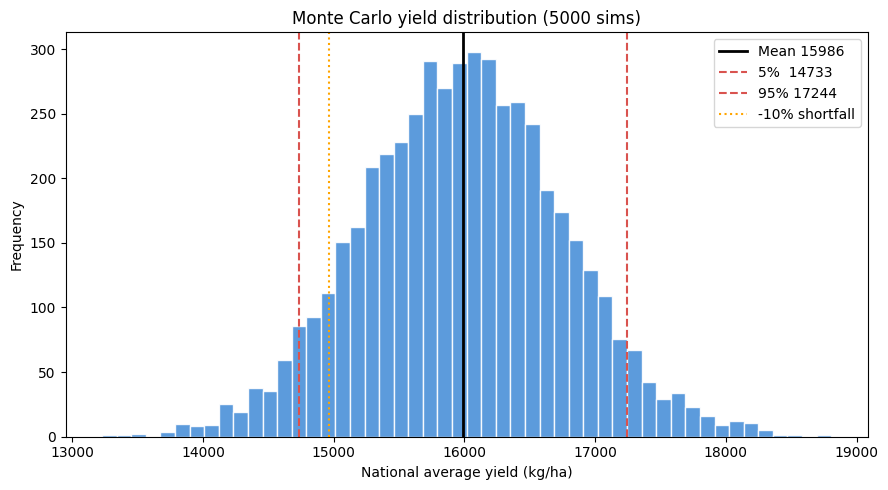

In [9]:
# ==================================================================
# 🎲 MONTE CARLO — uncertainty around the national average yield
# Propagates climate (temp/summer), input (N/pesticide), SALINITY (Delta
# intrusion) and physical-DAMAGE (flood/waterlogging) uncertainty through the
# agronomic engine. Reports a MEANINGFUL confidence band.
# ==================================================================
import numpy as np
np.random.seed(42)

N_SIMS  = 5000
crops   = base_y.index.tolist()
by      = base_y.values
aw      = area_w.values
sens    = np.array([TEMP_SENS.get(c, DEF) for c in crops])
sw      = np.array([SUMMER_WEIGHT[crop_season(c)] for c in crops])  # season-aware summer weight
salt    = np.array([SALT_LOSS.get(c, DEF_SALT) for c in crops])     # per-crop salt sensitivity

print(f'🎲 Running {N_SIMS} Monte Carlo simulations...')
mc_yields = np.empty(N_SIMS)
for i in range(N_SIMS):
    t   = np.random.normal(0, 0.8)          # annual warming SD ~0.8°C: matches Egypt's historical interannual temp variability
    s   = np.random.normal(0, 1.0)          # summer anomaly uncertainty
    nf  = np.random.uniform(0.85, 1.15)     # fertilizer availability
    pf  = np.random.uniform(0.85, 1.15)     # pesticide availability
    sal = np.clip(np.random.normal(0.15, 0.15), 0, None)  # Delta salinity intensity: mostly mild, occasional spikes
    dmg = np.random.uniform(0.95, 1.00)     # physical loss from extreme rain/flood events (national net, usually small)
    eff_T  = t + sw * s                     # per-crop: winter crops ~ignore summer term
    m_temp = np.clip(1 + sens * eff_T, 0, None)
    m_salt = np.clip(1 - salt * sal, 0, None)              # salinity channel (same form as yield_multiplier)
    mult   = m_temp * (nf ** ELAST_N) * (pf ** ELAST_PEST) * m_salt * dmg
    mc_yields[i] = (by * mult * aw).sum()

mean = mc_yields.mean()
ci_lo, ci_hi = np.percentile(mc_yields, [5, 95])
print(f'\n📊 Monte Carlo Results ({N_SIMS} runs) — national average yield:')
print(f'  Mean    : {mean:.0f} kg/ha')
print(f'  Std Dev : {mc_yields.std():.0f} kg/ha')
print(f'  90% CI  : [{ci_lo:.0f}, {ci_hi:.0f}] kg/ha')
print(f'  Range   : {(ci_lo-mean)/mean*100:+.1f}% to {(ci_hi-mean)/mean*100:+.1f}% around the mean')
print(f'  P(>10% shortfall) : {(mc_yields < baseline_abs*0.9).mean()*100:.1f}%')
print('\n  ✅ Reflects realistic near-term (2021–2040) uncertainty for Egypt:')
print('     climate + inputs + Delta salinity + extreme-rain damage channels.')

# ---- Distribution plot -------------------------------------------------
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(9,5))
    plt.hist(mc_yields, bins=50, color='#4a90d9', edgecolor='white', alpha=0.9)
    plt.axvline(mean,  color='black',   linestyle='-',  linewidth=2,   label=f'Mean {mean:.0f}')
    plt.axvline(ci_lo, color='#d9534f', linestyle='--', linewidth=1.5, label=f'5%  {ci_lo:.0f}')
    plt.axvline(ci_hi, color='#d9534f', linestyle='--', linewidth=1.5, label=f'95% {ci_hi:.0f}')
    plt.axvline(baseline_abs*0.9, color='orange', linestyle=':', linewidth=1.5, label='-10% shortfall')
    plt.xlabel('National average yield (kg/ha)'); plt.ylabel('Frequency')
    plt.title(f'Monte Carlo yield distribution ({N_SIMS} sims)')
    plt.legend(); plt.tight_layout(); plt.show()
except Exception as e:
    print('(plot skipped:', e, ')')


🌡️  Per-crop sensitivity (most vulnerable first):
Crop                   | Base (kg/ha) | Heatwave +2C | Comb.Stress | Salinity
------------------------------------------------------------------------------------
Maize                  |        7664 |  -28.43% 🔴 |  -48.89% 🔴 | -11.00% 🟡
Rice                   |        9189 |  -24.31% 🔴 |  -46.88% 🔴 | -18.00% 🔴
Soybeans               |        3007 |  -24.31% 🔴 |  -43.48% 🔴 | -10.00% 🟡
Peppers (green)        |       18342 |  -23.49% 🔴 |  -42.47% 🔴 | -10.00% 🟡
Tomatoes               |       41887 |  -22.25% 🔴 |  -40.96% 🔴 | -10.00% 🟡
Beans (dry)            |        3655 |  -22.25% 🔴 |  -42.30% 🔴 | -13.00% 🔴
Groundnuts             |        3595 |  -22.25% 🔴 |  -39.63% 🔴 |  -7.00% 🟡
Beans (green)          |       10557 |  -20.20% 🔴 |  -39.84% 🔴 | -13.00% 🔴
Cucumbers              |       24176 |  -20.20% 🔴 |  -38.45% 🔴 | -10.00% 🟡
Sunflower              |        2809 |  -20.20% 🔴 |  -37.06% 🔴 |  -7.00% 🟡
String beans           |        6907 

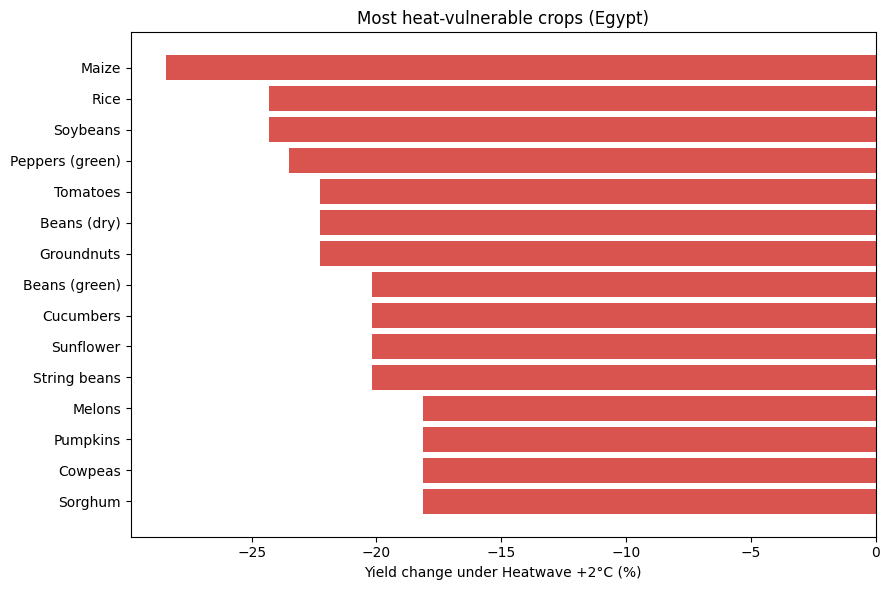

In [10]:
# ==================================================================
# 🌾 Per-crop climate sensitivity — which crops are most vulnerable?
# ==================================================================
heatwave_p = SCENARIOS['Heatwave +2C']
stress_p   = SCENARIOS['Combined Stress']
salinity_pure = {'temp_delta':0.0,'summer_delta':0.0,'n_factor':1.0,'pest_factor':1.0,'salinity':1.0}  # isolate salt effect

rows = []
for crop in sorted(base_y.index):
    b = base_y[crop]
    rows.append({
        'crop': crop,
        'base_yield_kgha': b,
        'heatwave_%':        (yield_multiplier(crop, heatwave_p) - 1) * 100,
        'combined_stress_%': (yield_multiplier(crop, stress_p)   - 1) * 100,
        'salinity_%':        (yield_multiplier(crop, salinity_pure) - 1) * 100,
    })
impact_df = pd.DataFrame(rows).sort_values('heatwave_%')

print('🌡️  Per-crop sensitivity (most vulnerable first):')
print(f"{'Crop':22s} | Base (kg/ha) | Heatwave +2C | Comb.Stress | Salinity")
print('-' * 84)
for _, r in impact_df.iterrows():
    i1 = '🔴' if r['heatwave_%'] < -10 else ('🟡' if r['heatwave_%'] < -5 else '🟢')
    i2 = '🔴' if r['combined_stress_%'] < -20 else ('🟡' if r['combined_stress_%'] < -10 else '🟢')
    i3 = '🔴' if r['salinity_%'] < -12 else ('🟡' if r['salinity_%'] < -6 else '🟢')
    print(f"{r['crop']:22s} | {r['base_yield_kgha']:11.0f} | {r['heatwave_%']:+7.2f}% {i1} | {r['combined_stress_%']:+7.2f}% {i2} | {r['salinity_%']:+6.2f}% {i3}")

try:
    import matplotlib.pyplot as plt
    top = impact_df.head(15)
    plt.figure(figsize=(9,6))
    plt.barh(top['crop'], top['heatwave_%'], color='#d9534f')
    plt.xlabel('Yield change under Heatwave +2°C (%)'); plt.title('Most heat-vulnerable crops (Egypt)')
    plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
except Exception as e:
    print('(plot skipped:', e, ')')


In [11]:
# ==================================================================
# 🛡️ ADAPTATION SCENARIOS — how much yield can we recover under Combined Stress?
# Each measure mitigates a specific stress channel:
#   . Drip Irrigation    -> restores ~70% of the water/nutrient input gap
#   . Tolerant Varieties -> cut heat loss ~35% + salinity loss ~40%
#   . Improved Drainage  -> flush salts, cut salinity loss ~65%
#   . Full Package       -> all three combined
# Central engineering estimates (FAO irrigation papers, ICARDA salt-tolerant
# breeding); tune freely in ADAPT_MEASURES.
# ==================================================================
ADAPT_MEASURES = {
    'Drip Irrigation':     {'drip':0.70},
    'Tolerant Varieties':  {'heat':0.35, 'salt':0.40},
    'Improved Drainage':   {'salt':0.65},
    'Full Package':        {'heat':0.35, 'drip':0.70, 'salt':0.65},
}
cs_base   = SCENARIOS['Combined Stress']
cs_mult   = np.array([yield_multiplier(c, cs_base) for c in base_y.index])
cs_yield  = float((base_y.values * cs_mult * area_w.values).sum())
cs_impact = (cs_yield - baseline_abs) / baseline_abs * 100

print('🛡️  Adaptation vs Combined Stress (national area-weighted yield):')
print(f"{'Strategy':22s} | Yield (kg/ha) | Impact %  | Recovery")
print('-' * 66)
print(f"{'No adaptation':22s} | {cs_yield:12.0f}  | {cs_impact:+7.2f}%  |   —")
adapt_results = {'No adaptation': {'impact_pct': cs_impact, 'recovered_pp': 0.0}}
for name, a in ADAPT_MEASURES.items():
    p = dict(cs_base); p['adaptation'] = a
    mult      = np.array([yield_multiplier(c, p) for c in base_y.index])
    abs_yield = float((base_y.values * mult * area_w.values).sum())
    impact    = (abs_yield - baseline_abs) / baseline_abs * 100
    recovered = impact - cs_impact   # percentage points of yield restored vs no action
    adapt_results[name] = {'impact_pct': impact, 'recovered_pp': recovered}
    print(f"{name:22s} | {abs_yield:12.0f}  | {impact:+7.2f}%  |  +{recovered:5.2f} pp")

print('\n✅ Adaptation valid: every measure reduces the Combined-Stress loss; Full Package recovers the most.')


🛡️  Adaptation vs Combined Stress (national area-weighted yield):
Strategy               | Yield (kg/ha) | Impact %  | Recovery
------------------------------------------------------------------
No adaptation          |        11480  |  -30.96%  |   —
Drip Irrigation        |        11967  |  -28.03%  |  + 2.93 pp
Tolerant Varieties     |        12874  |  -22.57%  |  + 8.39 pp
Improved Drainage      |        11909  |  -28.37%  |  + 2.58 pp
Full Package           |        13613  |  -18.13%  |  +12.83 pp

✅ Adaptation valid: every measure reduces the Combined-Stress loss; Full Package recovers the most.


In [12]:
# ==================================================================
# 💰 ECONOMIC LAYER — translate yield loss into EGP and food-security terms
# Production (tonnes) = recent-baseline area (ha) x baseline yield (kg/ha) / 1000.
# Farm-gate prices are ILLUSTRATIVE 2023/24 values (EGP/tonne); no price series
# exists in the FAO files, so replace PRICE_EGP_T with official ERAB/CAPMAS
# prices for a budget-grade estimate. Losses scale with each scenario's drop.
# ==================================================================
PRICE_EGP_T = {
    'Wheat':10000,'Maize':8000,'Rice':9000,'Barley':7000,'Cotton':30000,
    'Oranges':6000,'Lemons':8000,'Tangerines':7000,'Mangoes':12000,'Bananas':9000,
    'Dates':15000,'Apples':14000,'Figs':12000,'Grapes':12000,'Strawberries':18000,
    'Tomatoes':5000,'Peppers (green)':8000,'Potatoes':7000,'Onions':6000,'Eggplants':5000,
    'Cucumbers':6000,'Watermelons':4000,'Cabbages':3500,'Carrots':5000,'Okra':9000,
    'Artichokes':10000,'Broad Beans (dry)':16000,'Lentils':20000,'Chickpeas':20000,
    'Groundnuts':22000,'Sesame':40000,'Sunflower':18000,'Olives':12000,
    'Sugar beet':1500,'Sugar cane':1200,'Sweet Potatoes':6000,
    # ── newly added crops (illustrative EGP/tonne) ──
    'Sorghum':7000,'Rye':7000,'Soybeans':16000,
    'Beans (dry)':18000,'Beans (green)':9000,'Broad Beans (green)':9000,'String beans':9000,
    'Cowpeas':16000,'Peas (dry)':18000,'Peas (green)':9000,'Lupins':16000,'Vetches':8000,
    'Apricots':14000,'Peaches':12000,'Pears':14000,'Plums':12000,'Quinces':10000,
    'Stone Fruits (other)':12000,'Grapefruit':6000,'Walnuts':60000,
    'Melons':6000,'Pumpkins':4000,'Taro':7000,
    'Cauliflower & Broccoli':5000,'Lettuce':5000,'Spinach':5000,'Garlic':12000,
    'Peppers (dry)':30000,'Flax':12000,'Jute':8000,'Linseed':18000,'Spices':35000,
}
DEF_PRICE = 8000          # EGP/tonne fallback for any unlisted crop
STAPLES   = ('Wheat','Maize','Rice')

area_abs = ref.groupby('crop')['area_ha'].mean().reindex(base_y.index).fillna(0.0)  # ha, recent window
prod_t   = base_y * area_abs / 1000.0   # baseline production per crop (tonnes/yr)
print(f"🌾 Baseline national production (recent window): {prod_t.sum()/1e6:6.2f} M tonnes/yr\n")

def econ_loss(p):
    loss_egp = 0.0; total_t = 0.0; staple_t = 0.0
    for c in base_y.index:
        loss_frac = 1 - yield_multiplier(c, p)
        loss_t    = float(prod_t[c]) * loss_frac
        loss_egp += loss_t * PRICE_EGP_T.get(c, DEF_PRICE)
        total_t  += loss_t
        if c in STAPLES: staple_t += loss_t
    return loss_egp, total_t, staple_t

ECON_SCENARIOS = ['Heatwave +2C','Drought (-20% inputs)','Heavy Rain +20%',
                  'Salinity Intrusion (Delta)','Combined Stress']
print(f"{'Scenario':26s} | Loss (EGP bn) | Output loss (Mt) | Staple loss (Mt)")
print('-' * 82)
for name in ECON_SCENARIOS:
    egp, tot_t, stap_t = econ_loss(SCENARIOS[name])
    print(f"{name:26s} | {egp/1e9:11.1f}  | {tot_t/1e6:14.2f}  | {stap_t/1e6:13.2f}")

egp_cs, tot_cs, stap_cs = econ_loss(SCENARIOS['Combined Stress'])
base_staple = float(prod_t.reindex(list(STAPLES)).sum())
print(f"\n🍞 Food security (Combined Stress): staples (wheat+maize+rice) output falls "
      f"{stap_cs/1e6:.2f} Mt ({stap_cs/base_staple*100:.1f}% of staple output).")
print(f"   Egypt already imports ~half its wheat, so a domestic shortfall of this size "
      f"widens the import bill and raises food-security risk.")

p_full = dict(SCENARIOS['Combined Stress']); p_full['adaptation'] = ADAPT_MEASURES['Full Package']
egp_full, _, _ = econ_loss(p_full)
print(f"\n💡 Full adaptation package cuts the Combined-Stress loss from "
      f"{egp_cs/1e9:.1f} to {egp_full/1e9:.1f} EGP bn (avoided loss ≈ {(egp_cs-egp_full)/1e9:.1f} EGP bn/yr).")


🌾 Baseline national production (recent window):  93.97 M tonnes/yr

Scenario                   | Loss (EGP bn) | Output loss (Mt) | Staple loss (Mt)
----------------------------------------------------------------------------------
Heatwave +2C               |        92.7  |          13.84  |          4.56
Drought (-20% inputs)      |        66.2  |          10.10  |          3.00
Heavy Rain +20%            |        55.3  |           8.88  |          1.98
Salinity Intrusion (Delta) |        77.5  |          10.96  |          3.33
Combined Stress            |       194.1  |          29.09  |          8.69

🍞 Food security (Combined Stress): staples (wheat+maize+rice) output falls 8.69 Mt (39.4% of staple output).
   Egypt already imports ~half its wheat, so a domestic shortfall of this size widens the import bill and raises food-security risk.

💡 Full adaptation package cuts the Combined-Stress loss from 194.1 to 113.8 EGP bn (avoided loss ≈ 80.3 EGP bn/yr).


In [13]:
# ==================================================================
# 📋 MASTER SUMMARY — all results consolidated in one place
# ==================================================================
import pandas as pd

# --- Scenarios (impact + risk + economic loss) ---
_rows = []
for name, r in scenario_results.items():
    egp, tot_t, stap_t = econ_loss(SCENARIOS[name])
    _rows.append({
        'Scenario'        : name,
        'Yield (kg/ha)'   : round(r['mean_yield']),
        'Impact %'        : round(r['impact_pct'], 2),
        'Risk'            : r['risk'],
        'Loss (EGP bn)'   : round(egp/1e9, 1),
        'Output loss (Mt)': round(tot_t/1e6, 2),
    })
summary_df = pd.DataFrame(_rows)
print('📋 MASTER SUMMARY — Climate / input scenarios')
print('=' * 78)
print(summary_df.to_string(index=False))

# --- Monte Carlo uncertainty band ---
print('\n🎲 Monte Carlo (national avg yield):')
print(f'   Mean {mean:.0f} kg/ha | 90% CI [{ci_lo:.0f}, {ci_hi:.0f}] '
      f'({(ci_lo-mean)/mean*100:+.1f}% to {(ci_hi-mean)/mean*100:+.1f}%) | '
      f'P(>10% shortfall) {(mc_yields < baseline_abs*0.9).mean()*100:.1f}%')

# --- Adaptation recovery vs Combined Stress ---
print('\n🛡️ Adaptation vs Combined Stress:')
adapt_df = pd.DataFrame([
    {'Strategy': k, 'Impact %': round(v['impact_pct'], 2),
     'Recovered (pp)': round(v['recovered_pp'], 2)}
    for k, v in adapt_results.items()
])
print(adapt_df.to_string(index=False))

print('\n✅ One-glance takeaway: Combined Stress is the worst case; Tech+Green is the')
print('   only upside; the Full adaptation package recovers the most yield (pp).')


📋 MASTER SUMMARY — Climate / input scenarios
                  Scenario  Yield (kg/ha)  Impact %     Risk  Loss (EGP bn)  Output loss (Mt)
                  Baseline          16627      0.00 منخفضة 🟢            0.0              0.00
              Heatwave +2C          14178    -14.73  عالية 🔴           92.7             13.84
     Drought (-20% inputs)          14839    -10.75  عالية 🔴           66.2             10.10
           Heavy Rain +20%          15056     -9.45 متوسطة 🟡           55.3              8.88
           Combined Stress          11480    -30.96  عالية 🔴          194.1             29.09
Salinity Intrusion (Delta)          14688    -11.66  عالية 🔴           77.5             10.96
              Tech + Green          17903      7.67 منخفضة 🟢          -46.7             -7.21

🎲 Monte Carlo (national avg yield):
   Mean 15986 kg/ha | 90% CI [14733, 17244] (-7.8% to +7.9%) | P(>10% shortfall) 8.9%

🛡️ Adaptation vs Combined Stress:
          Strategy  Impact %  Recovered (pp)


In [14]:
import joblib, os, json, numpy as np, pandas as pd

# ── 1. مجلد الحفظ على Drive ──────────────────────────────────
SAVE_DIR = os.path.join(DRIVE_FOLDER, "module3_model")
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 2. استخلاص crop_stats (trend + std لكل محصول) ───────────
#   ده اللي بيُحوّل الـ deviation المتوقع → absolute kg/ha وقت الـ inference
crop_stats = {}
for crop, grp in df_m.groupby('crop'):
    train_g = grp[grp['year'] <= TRAIN_UNTIL]
    if len(train_g) >= 4:
        coeffs = np.polyfit(train_g['year'], train_g['yield_kg_ha'], 1).tolist()
    else:
        coeffs = [0.0, float(train_g['yield_kg_ha'].mean())]
    std = float(grp['crop_yield_std'].iloc[0])
    crop_stats[crop] = {'trend_coeffs': coeffs, 'yield_std': std}

# ── 3. Feature medians (للـ fillna وقت الـ inference) ────────
feature_medians = df_m[ML_FEATURES].median().to_dict()

# ── 4. Metadata ───────────────────────────────────────────────
meta = {
    'best_model_name'  : best_name,
    'ML_FEATURES'      : ML_FEATURES,
    'TRAIN_UNTIL'      : TRAIN_UNTIL,
    'TARGET'           : TARGET,
    'HAS_PRECIP'       : HAS_PRECIP,
    'feature_medians'  : feature_medians,
    'crop_stats'       : crop_stats,
    'le_classes'       : le.classes_.tolist(),
}

# ── 5. الحفظ الفعلي ──────────────────────────────────────────
joblib.dump(best_model, os.path.join(SAVE_DIR, 'best_model.joblib'))
with open(os.path.join(SAVE_DIR, 'meta.json'), 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"✅ تم الحفظ في: {SAVE_DIR}")
print(f"   📦 best_model.joblib  → {best_name}")
print(f"   📋 meta.json          → features ({len(ML_FEATURES)}), crop_stats ({len(crop_stats)} crops)")
print(f"\n🗂️  الملفات:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"   {f}  ({size:.1f} MB)")



✅ تم الحفظ في: /content/drive/MyDrive/Colab Notebooks/Hosny/data/module3_model
   📦 best_model.joblib  → Random Forest
   📋 meta.json          → features (26), crop_stats (68 crops)

🗂️  الملفات:
   best_model.joblib  (1.6 MB)
   meta.json  (0.0 MB)


In [15]:
# ============================================================
# CELL 2 — 🔄 تحميل الموديل (في أي Notebook تاني)
# ============================================================
# الصق الـ cell ده في notebook الـ inference وشغّله

import joblib, json, numpy as np, pandas as pd
from sklearn.preprocessing import LabelEncoder

# ── نفس المسار اللي حفظت فيه ─────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Hosny/data/module3_model"

# ── تحميل الموديل ────────────────────────────────────────────
best_model = joblib.load(os.path.join(SAVE_DIR, 'best_model.joblib'))

# ── تحميل الـ metadata ────────────────────────────────────────
with open(os.path.join(SAVE_DIR, 'meta.json'), encoding='utf-8') as f:
    meta = json.load(f)

best_name       = meta['best_model_name']
ML_FEATURES     = meta['ML_FEATURES']
TRAIN_UNTIL     = meta['TRAIN_UNTIL']
feature_medians = meta['feature_medians']
crop_stats      = meta['crop_stats']   # dict: crop → {trend_coeffs, yield_std}

# إعادة بناء LabelEncoder من الـ classes المحفوظة
le = LabelEncoder()
le.classes_ = np.array(meta['le_classes'])

print(f"✅ تم التحميل: {best_name}")
print(f"   Features: {len(ML_FEATURES)} | Crops: {len(crop_stats)}")

# ── دالة predict_abs_yield للاستخدام في الـ inference ─────────
def predict_abs_yield_from_features(row_dict, crop_name, target_year):
    """
    row_dict  : dict بقيم الـ features (أي feature مش موجود بيتعوّض بالـ median)
    crop_name : اسم المحصول (بالإنجليزي كما في le.classes_)
    target_year: السنة المطلوب التوقع فيها
    """
    # إعداد الـ feature vector
    X = {feat: row_dict.get(feat, feature_medians[feat]) for feat in ML_FEATURES}
    X_df = pd.DataFrame([X])

    # التوقع على الـ deviation
    dev_std = best_model.predict(X_df)[0]

    # تحويل → absolute kg/ha باستخدام trend المحصول
    if crop_name in crop_stats:
        coeffs = crop_stats[crop_name]['trend_coeffs']
        trend  = np.polyval(coeffs, target_year)
        std    = crop_stats[crop_name]['yield_std']
    else:
        raise ValueError(f"المحصول '{crop_name}' مش في الموديل. الأسماء المتاحة:\n{list(crop_stats.keys())}")

    abs_yield = dev_std * std + trend
    return max(0.0, abs_yield)  # yield مش بتبقى سالبة


# ── مثال سريع ────────────────────────────────────────────────
if __name__ == "__main__":
    # مثال: توقع محصول القمح سنة 2025 بـ features من الـ median
    test_crop = 'Wheat'
    test_year = 2025
    sample_features = {}  # في الحالة دي بيستخدم الـ medians كلها تلقائياً

    result = predict_abs_yield_from_features(sample_features, test_crop, test_year)
    print(f"\n🌾 مثال: {test_crop} — {test_year}")
    print(f"   Predicted Yield: {result:,.0f} kg/ha")


✅ تم التحميل: Random Forest
   Features: 26 | Crops: 68

🌾 مثال: Wheat — 2025
   Predicted Yield: 8,189 kg/ha
